# Машинное обучение, ФКН ВШЭ #

## Практическое задание 5. Решающие деревья ##

### Общая информация ###

Дата выдачи: 16.04.2026

Мягкий дедлайн: 30.04.2026 23:59

Жесткий дедлайн:  05.05.2026 23:59

### О задании

В процессе выполнения этого домашнего задания вы:

1. Попрактикуетесь использовать решающие деревья из `sklearn` для задачи классификации на простых двумерных датасетах, научитесь визуализировать разделяющие плоскости и распознавать переобучение.

2. Реализуете своё решающее дерево для задачи классификации и сравните его со стандартной имплементацией.

3. Исследуете влияние бэггинга на смещение и разброс.

### Оценивание и штрафы

Каждая из задач имеет определенную стоимость, которая указана в скобках около номера задачи. Максимально допустимая оценка за работу $-$ 10 баллов.

Задание выполняется самостоятельно. "Похожие" решения считаются плагиатом: все задействованные студенты (в том числе те, у кого списали) получают не более 0 баллов. Если вы использовали внешний источник (даже частично), укажите ссылку в отдельном блоке в конце работы.

Неэффективная реализация кода может негативно отразиться на оценке.

**Устная проверка.** Для проверки понимания кода и выводов студент может быть приглашён на устную защиту. Оценка за задание может быть изменена после устной защиты. Если студент не может объяснить ключевые части решения и принятые решения, работа считается недобросовестной и оценивается в 0 баллов независимо от автотестов.


### Формат сдачи

Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-05-trees-Username.ipynb
* Модуль hw5code.py
* Номера лучших посылок в [Яндекс.Контесте](https://new.contest.yandex.ru/contests/72204/start) для обеих задач

В [Яндекс.Контест](https://new.contest.yandex.ru/contests/72204/start) нужно отправить файл hw5code.py с реализованными функциями и классами.

Для удобства проверки самостоятельно посчитайте свою максимальную оценку (исходя из набора решенных задач) и укажите ниже:

__Оценка:__ 10

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

np.random.seed(0)

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.preprocessing import LabelEncoder
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')

from hw5code import find_best_split
from hw5code import DecisionTree

## Решающие деревья

### Визуализация (1 балл)

Рассмотрим три простых двумерных датасета, сгенерированных с помощью `make_moons`, `make_circles` и `make_classification`.

In [2]:
from sklearn.datasets import make_moons, make_circles, make_classification

datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2,
                        class_sep=0.75, random_state=3, n_redundant=0)
]

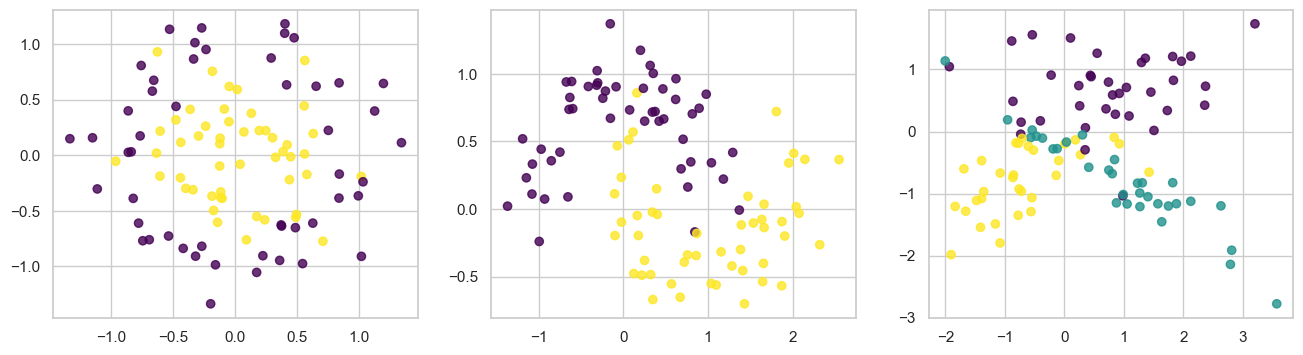

In [3]:
plt.figure(figsize=(16, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap="viridis", alpha=0.8)

__Задание 1. (0.5 балла)__

Для каждого датасета обучите решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Постройте разделящие поверхности и посчитайте accuracy на обучающей и тестовой выборках. Прокомментируйте, в каких случаях и почему модель переобучается.

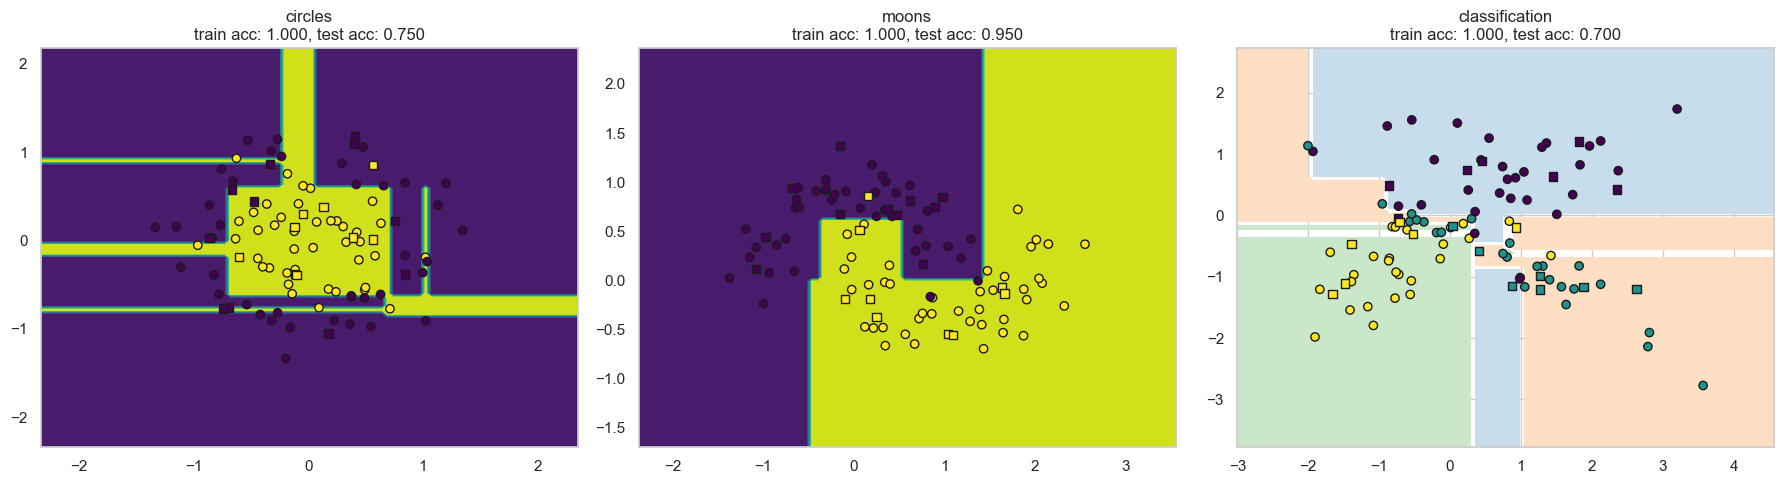

In [4]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (X, y) in enumerate(datasets):
    ax = axes[i]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=69)
    clf = DecisionTreeClassifier(random_state=69)
    clf.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))

    DecisionBoundaryDisplay.from_estimator(clf, X, cmap='viridis', ax=ax)
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', edgecolors='k', marker='o')
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='viridis', edgecolors='k', marker='s')
    ax.set_title(f"{['circles','moons','classification'][i]}\ntrain acc: {train_acc:.3f}, test acc: {test_acc:.3f}")
plt.tight_layout()
plt.show()

__Ответ:__

Кажется, что в первом случае модель переобучена, потому что она очень сильно подтроилась под данные и сам прогноз выглядит рваным и не сплошным. Во втором случае модель хорошо обобщила все наблюдения и кажется, что переоюучение тут имеет место в наименьшей степени. В третьем же случае нет такх же проблем, как в первом, но все еще прослеживается подгон под данные и плохая обощенность прогнозов.

Касательно причин думаю, что в во втором случае сами данные имеют более легкий характер для предказания, поэтому обучить нормальную модель легче + для этого нужно меньше данных. Во всех остальных случаях нужно больше данных и более слоные модели, чтобы достичь хороших результатов без переобучения.
Плюс во втором случае достаточно мало наблюдений, которые похожи друг на друга, поэтому модели легче обобщать и обучаться.

Еще мы не задавали никаких ограничени на глубину дерева, поэтому и получили такие перебученные результаты на train

__Задание 2. (0.5 балла)__

Выберите один датасет из предыдущего задания и исследуйте на его примере влияние на итоговое качество двух гиперпараметров (любых на ваш выбор) одновременно. Для каждой пары значений посчитайте accuracy на обучающей и тестовой выборках и сохраните результаты в таблицу.

Визуализируйте зависимость качества на тестовой выборке от значений выбранных вами гиперпараметров. При каких значениях наблюдается лучшее соотношение разброса и смещения? Почему вы сделали такой вывод?

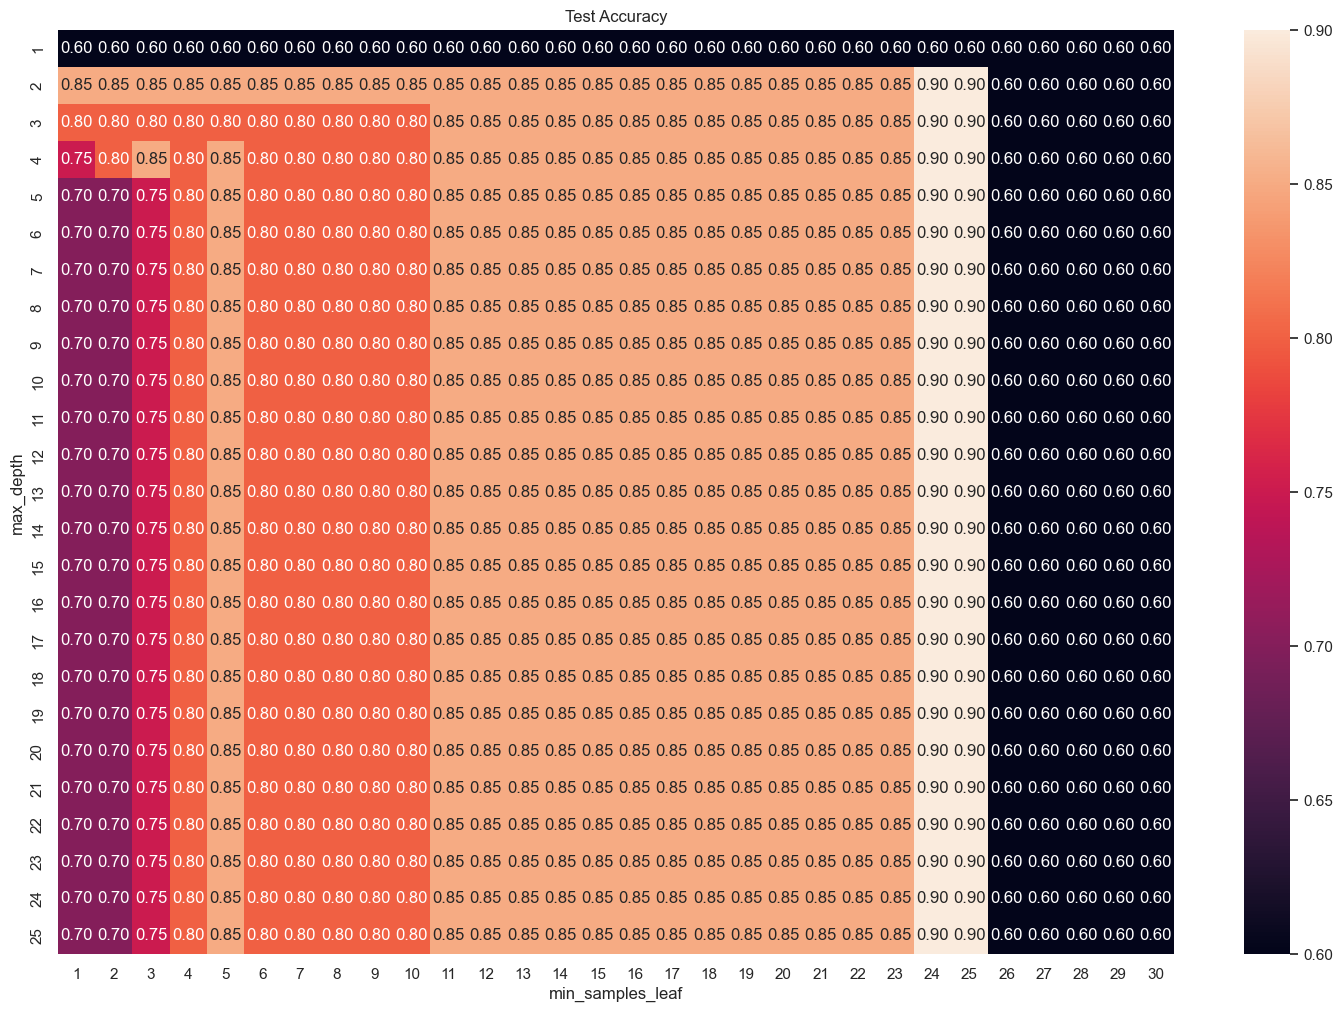

In [5]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
X, y = datasets[2]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=69)

results = []
for i in range(1, 26):
    for j in range(1, 31):
        clf = DecisionTreeClassifier(max_depth=i, min_samples_leaf=j, random_state=69)
        clf.fit(X_train, y_train)
        train_acc = accuracy_score(y_train, clf.predict(X_train))
        test_acc = accuracy_score(y_test, clf.predict(X_test))
        results.append({
            'max_depth': i,
            'min_samples_leaf': j,
            'train_accuracy': train_acc,
            'test_accuracy': test_acc
        })

df_temp = pd.DataFrame(results)
pivot = df_temp.pivot(index='max_depth', columns='min_samples_leaf', values='test_accuracy')


plt.figure(figsize=(18, 12))
sns.heatmap(pivot, annot=True, fmt=".2f")
plt.title("Test Accuracy")
plt.xlabel("min_samples_leaf")
plt.ylabel("max_depth")
plt.show()

__Ответ:__

Чем больше глубина и меньше минимальное кол-во объектов в листах, тем выше шанс переобучения. По этой причине при росте глубины accuracy склонна падать, если конечно сложность дерева позволяет нормально классифицировать. Если глубина слишком маленькая, то модель не может нормально предсказать, поскольку слишком простая модель. Это все мы можем наблюдать смотря на значения сверху-вниз. 

Справа модель является слишком простой и не особо разделяет объекты, поэтому мы и получаем такие низкие показатели accuracy.

Посередине у нас достаточно хорошая способность к обощению и достаточно сложная модель (клетки посередине со значением 0.85), но можем попробовать взять параметры с min_samples_leaf = 5 и глубиной 10, чтобы избежать риска переобучения.

### Решающие деревья своими руками (6 баллов)

Итак, пришло время реализовать свой класс для обучения решающего дерева.

__Задание 3. (1.5 балла)__

Реализуйте функцию `find_best_split` из модуля `hw5code.py` согласно алгоритму, расказанному на лекции; её сигнатура и докстринг с дополнительными требованиями и указаниями прописаны в файле.

Напоминаем, что под критерием Джини подразумевается следующая функция качества разбиения:

$$
Q(R, R_l, R_r) = -\frac{|R_l|}{|R|} H(R_l) - \frac{|R_r|}{|R|} H(R_r),
$$

где $R$ - множество объектов, $R_l$ и $R_r$ - объекты, попавшие в левое и правое поддерево соответственно.

Функция неоднородности Джини для множества $R$ определяется как

$$
H(R) = 1 - \sum_{k=1}^{K} p_k^2,
$$

где $p_k$ - доля объектов класса $k$ в множестве $R$, а $K$ - число различных классов в текущем узле.

Замечание: при $K=2$ формула сводится к бинарному случаю $H(R)=1-p_0^2-p_1^2$, где $p_1$ и $p_0$ $-$ доля объектов классов $1$ и $0$ соответственно.


__Задание 4. (0.75 балл)__

Загрузите датасет [Student Performance](https://archive.ics.uci.edu/dataset/320/student+performance). Поработайте с данными: создайте бинарный признак `pass`, который будет равен единице, если итоговая оценка `G3` не меньше $10$, и нулю в противном случае. Затем выберите пять числовых признаков, среди которых должны быть как очень информативные, так и потенциально неинформативные. Коротко обоснуйте свой выбор.

Для каждого из выбранных признаков постройте график зависимости критерия Джини от возможного порога разделения. Отобразите все пять кривых на одном рисунке.

Для каждого из выбранных признаков дополнительно визуализируйте зависимость
"значение признака - класс (0/1)".

> Можно, например, построить scatter-график, где по оси X - значение признака, а по оси Y - бинарный признак `pass` (при необходимости используйте небольшой jitter по оси Y и/или прозрачность alpha, чтобы лучше видеть плотность точек); или использовать эквивалентную по смыслу визуализацию (например, `seaborn.stripplot` / `swarmplot`), из которой видно, как распределены значения признака внутри каждого класса.

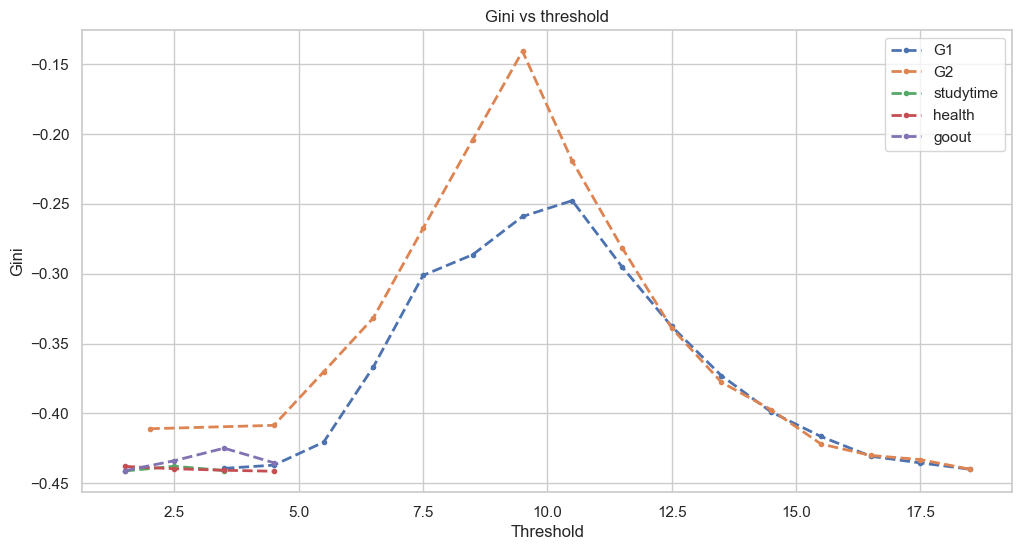

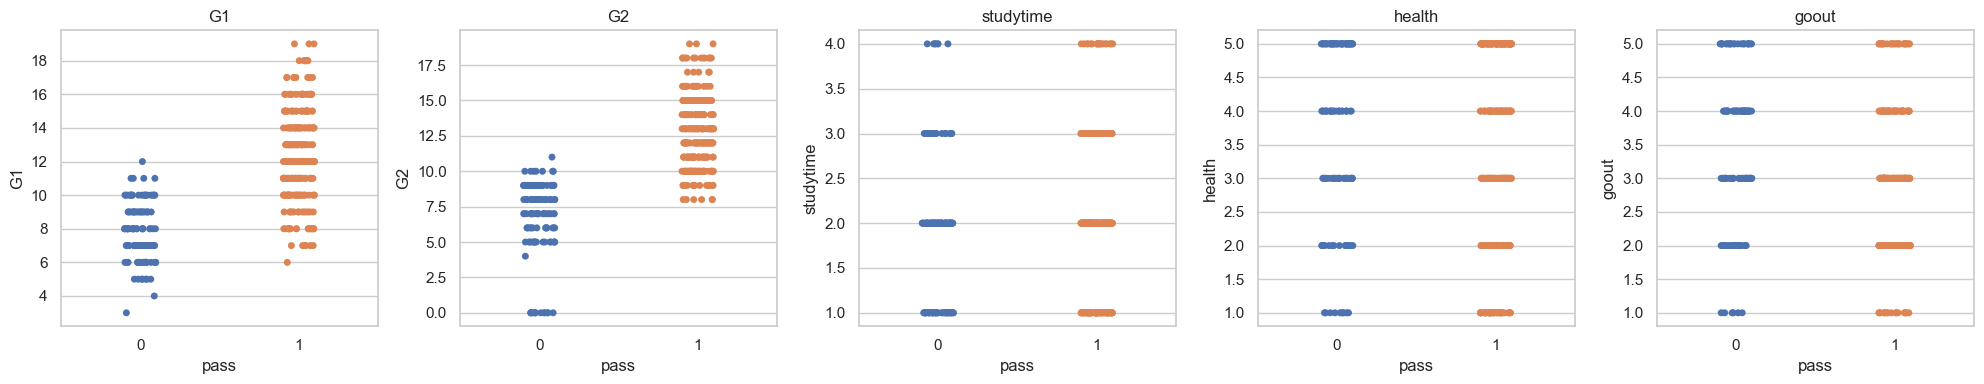

In [6]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ

df = pd.read_csv('student-mat.csv', sep=';')
df['pass'] = (df['G3'] >= 10).astype(int)

features = ['G1', 'G2', 'studytime', 'health', 'goout']

plt.figure(figsize=(12, 6))
for feat in features:
    x = df[feat].values
    y = df['pass'].values
    thresholds, ginis, _, _ = find_best_split(x, y)
    plt.plot(thresholds, ginis, linestyle='--', linewidth=2, marker='.', label=feat)
plt.xlabel('Threshold')
plt.ylabel('Gini')
plt.title('Gini vs threshold')
plt.legend()
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, feat in enumerate(features):
    ax = axes[i]
    sns.stripplot(data=df, x='pass', y=feat, ax=ax, hue='pass', legend=False, jitter=True)
    ax.set_title(feat)
    ax.set_xlabel('pass')
plt.tight_layout()
plt.show()

__Ответ:__

g1 и g2 напрямую должно очень хорошо объяснять pass
studytime в теории слегка должно помогать (но в итоге признак получился неинформативным)
health и goout брал просто как косвенные факторы влияющие на pass (почти незначительные)


__Задание 5. (0.25 балла)__

На основании построенных в прошлом задании графиков ответьте на следующие вопросы:

1. По какому признаку нужно производить деление выборки на два поддерева? Почему?

2. Согласуется ли этот результат с тем, что видно на scatter-графиках? Совпадают ли выводы?

3. Как выглядят кривые для тех признаков, по которым классы разделяются почти идеально? Чем отличаются от них кривые для признаков, по которым деление практически невозможно?

**Ответ:**
1. Можно делить по G2 или G1, они довольно хорошо делят тех, у кого pass и у кого нет. Мжно делить потому, что хорошо коррелирует с pass и довольно мало пересечений
2. На графике видно, что распределение в каждой группе довольно сильно отличаются для этих двух признаков. Только G2 чуть лучше делит на две группы, чем G1.
3. В G2 мы видим, что довольно хорошо получилось разделить группы при трешхолде чуть меньше 10, такой сильный рост верх дает джини чуть больше -0.15. Чем ближе gini к 0, тем лучше признак себя показал при разделении групп. Кривые ля признаков, по которым деление почти невозможно будут двать низкие значения gini (почти -0.5), что обозначает, что группы не делятся нормально ни при каком трешхолде. 

Какие-то графики присутсвуют неполностью, потому что у каждого признака свои min и max значения, поэтому какие-то трешхолды для них бесполезны.

__Задание 6. (1.5 балла)__

Разберитесь с уже написанным кодом в классе `DecisionTree` модуля `hw5code.py`. Исправьте ошибки в методе `_fit_node`, а также реализуйте `_predict_node`.

В данном задании:
* построение дерева осуществляется согласно базовому жадному алгоритму, предложенному на лекции
* выбор лучшего разбиения необходимо производить по критерию Джини
* в качестве критерия останова используется следующий: все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку
* ответ в листе $-$ это наиболее часто встречающийся в нём класс
* для категориальных признаков выполняется преобразование, описанное на лекции (можете найти его в конспекте в разделе «Учёт категориальных признаков»)

__Задание 7. (0.5 балла)__

Протестируйте написанное вами решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Для этого необходимо скачать таблицу agaricus-lepiota.data и применить к каждому столбцу LabelEncoder, чтобы преобразовать строковые имена категорий в натуральные числа.

Первый столбец в рассматриваемой таблице $-$ это целевая переменная ('e' $-$ edible, 'p' $-$ poisonous).

Обучите решающее дерево на $50\%$ случайно выбранных объектов и получите предсказания для оставшейся половины. Вычислите accuracy. Если в предыдущих заданиях вы всё сделали корректно, то у вас должно получиться качество очень близкое единице или даже равное ей.

In [7]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ

columns = [
    "class", "cap-shape", "cap-surface", "cap-color", "bruises", "odor",
    "gill-attachment", "gill-spacing", "gill-size", "gill-color",
    "stalk-shape", "stalk-root", "stalk-surface-above-ring",
    "stalk-surface-below-ring", "stalk-color-above-ring",
    "stalk-color-below-ring", "veil-type", "veil-color", "ring-number",
    "ring-type", "spore-print-color", "population", "habitat"
]
df_mushrooms = pd.read_csv("agaricus-lepiota.data", header=None, names=columns)

# использовал гпт, чтобы датасет загрузить и в норм формат привести

encoders = {}
for col in df_mushrooms.columns:
    encoder = LabelEncoder()
    df_mushrooms[col] = encoder.fit_transform(df_mushrooms[col])
    encoders[col] = encoder

X = df_mushrooms.drop("class", axis=1).values
y = df_mushrooms["class"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=69, stratify=y)

feature_types = ["categorical"] * X.shape[1]

tree = DecisionTree(feature_types=feature_types)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc}")


Accuracy: 1.0


__Задание 8. (1 балл)__

Реализуйте в классе `DecisionTree` поддержку параметров `max_depth`, `min_samples_split` и `min_samples_leaf` по аналогии с `sklearn.tree.DecisionTreeClassifier`.

__Задание 9. (0.5 балла)__

Проверьте, спасают эти параметры вас от переобучения.

Для этого **решите при помощи собственной имплементации `DecisionTree`  задачу классификации цвета вина** (color) по его химическим характеристикам на датасете [Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality).

Как обычно, случайно разбейте свой датасет на тест-трейн (в отношении 7:3), и далее сравните на них поведение двух деревьев:
- Для первого дерева не используйте параметры из задания 8
- Для второго дерева выберите разумные значения этих параметров (в этом конкретном случае мы рекомендуем `max_depth=8, min_samples_leaf=5, min_samples_split=17`), и постройте дерево с их использованием.
  - Подбирать оптимальные параметры здесь не требуется

Выведите метрики качества классификации. **Что вы наблюдаете, и почему так произошло?**


В качестве sanity check сравните качество работы и структуру вашего второго дерева с результатом стандартной имплементации из `sklearn`. Не забудьте подать ему на вход те же параметры.

**Обратите внимание, что в оригинале таргетом является качество вина; мы же с вами предсказываем его цвет.** В каком-то смысле, это модель-сомелье.


*Андер-сэмплирование данных далее сделано специально, чтобы продемонстрировать должный эффект. Убирать его запрещается.*

In [20]:
from ucimlrepo import fetch_ucirepo

np.random.seed(0)

wine_quality = fetch_ucirepo(id=186)


In [21]:
df = wine_quality.data.original.sample(frac=0.1)

X = df.drop(columns=['color'])
y = df['color']


In [22]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 650 entries, 5316 to 5545
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         650 non-null    float64
 1   volatile_acidity      650 non-null    float64
 2   citric_acid           650 non-null    float64
 3   residual_sugar        650 non-null    float64
 4   chlorides             650 non-null    float64
 5   free_sulfur_dioxide   650 non-null    float64
 6   total_sulfur_dioxide  650 non-null    float64
 7   density               650 non-null    float64
 8   pH                    650 non-null    float64
 9   sulphates             650 non-null    float64
 10  alcohol               650 non-null    float64
 11  quality               650 non-null    int64  
dtypes: float64(11), int64(1)
memory usage: 66.0 KB


In [23]:
y.info()

<class 'pandas.core.series.Series'>
Index: 650 entries, 5316 to 5545
Series name: color
Non-Null Count  Dtype 
--------------  ----- 
650 non-null    object
dtypes: object(1)
memory usage: 10.2+ KB


In [24]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
from sklearn.tree import DecisionTreeClassifier as SklearnDT

y = (df['color'] == 'white').astype(int)  # чтобы убрать str в таргете


X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.3, random_state=42, stratify=y.values
)

feature_types = ["real"] * X.shape[1]

tree_basic = DecisionTree(feature_types=feature_types)
tree_basic.fit(X_train, y_train)
train_acc_basic = accuracy_score(y_train, tree_basic.predict(X_train))
test_acc_basic = accuracy_score(y_test, tree_basic.predict(X_test))
print(f"Train accuracy basic: {train_acc_basic:.4f}")
print(f"Test accuracy basic:  {test_acc_basic:.4f}")


tree = DecisionTree(
    feature_types=feature_types,
    max_depth=8,
    min_samples_leaf=5,
    min_samples_split=17
)
tree.fit(X_train, y_train)
train_acc = accuracy_score(y_train, tree.predict(X_train))
test_acc = accuracy_score(y_test, tree.predict(X_test))
print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")


sk_tree = SklearnDT(
    max_depth=8,
    min_samples_leaf=5,
    min_samples_split=17,
    random_state=42
)
sk_tree.fit(X_train, y_train)
train_acc_sk = accuracy_score(y_train, sk_tree.predict(X_train))
test_acc_sk = accuracy_score(y_test, sk_tree.predict(X_test))
print(f"Train accuracy sk: {train_acc_sk:.4f}")
print(f"Test accuracy sk:  {test_acc_sk:.4f}")

# поменял random_state на 42, потому что лучше видна разница на тесте, чем при 69


Train accuracy basic: 1.0000
Test accuracy basic:  0.9590
Train accuracy: 0.9824
Test accuracy:  0.9744
Train accuracy sk: 0.9824
Test accuracy sk:  0.9744


In [25]:
from sklearn.metrics import classification_report


print(classification_report(y_test, tree_basic.predict(X_test)))
print(classification_report(y_test, tree.predict(X_test)))
print(classification_report(y_test, sk_tree.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      0.85      0.91        47
           1       0.95      0.99      0.97       148

    accuracy                           0.96       195
   macro avg       0.97      0.92      0.94       195
weighted avg       0.96      0.96      0.96       195

              precision    recall  f1-score   support

           0       1.00      0.89      0.94        47
           1       0.97      1.00      0.98       148

    accuracy                           0.97       195
   macro avg       0.98      0.95      0.96       195
weighted avg       0.98      0.97      0.97       195

              precision    recall  f1-score   support

           0       1.00      0.89      0.94        47
           1       0.97      1.00      0.98       148

    accuracy                           0.97       195
   macro avg       0.98      0.95      0.96       195
weighted avg       0.98      0.97      0.97       195



Выводы:

Видим, что все метрики на train упали, на фоне базовой версии без параметров. Это нормально, поскольку мы избавлялись от переобучения, поэтому результаты и упали. Зато видим рост метрик на test, что означает, что модель лучше стала обобщать и более точно делить на классы. Еще видим, что sklearn полностью совпал с моей реализацией, это нормально, поскольку мы дали одни и те же параметры на вход, что и дает нам те же результаты, поскольку они работают одинаково. (Специально поправлена логика в выборе наилучшего сплита, когда добавлялась версия с доп гиперпараметрами)

## Bias-variance decomposition (3 балла)

В этой части задания воспользуемся возможностями бутстрапа для оценки смещения и разброса алгоритмов машинного обучения.

В этом разделе мы будем работать с датасетом `California housing` из `sklearn.datasets.fetch_california_housing`. Это задача регрессии: по признакам района (доход, возраст домов и т.п.) нужно предсказать MedHouseVal - медианная стоимость жилья.

In [26]:
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing()
X = california["data"]
y = california["target"]

X.shape, y.shape

((20640, 8), (20640,))

Во всех заданиях этого раздела (задания 10-11) используйте одни и те же данные `X, y` и три стандартные модели из sklearn:

* `LinearRegression`
* `DecisionTreeRegressor`
* `RandomForestRegressor`

Все три модели имеют единый интерфейс, что позволит передавать их в общие функции.


### Вычисление bias и variance (1.5 балл)

На [лекции](https://github.com/esokolov/ml-course-hse/blob/master/2024-fall/lecture-notes/lecture08-ensembles.pdf) была выведена следующая формула, показывающая, как можно представить ошибку алгоритма регрессии в виде суммы трех компонент:
$$
L(\mu) =
    \mathbb{E}_{x, y}\bigl[\mathbb{E}_{X}\bigl[ (y - \mu(X)(x))^2 \bigr]\bigr] =
$$

$$
    \underbrace{\mathbb{E}_{x, y}\bigl[(y - \mathbb{E}[y|x] )^2\bigr]}_{\text{шум}} + \underbrace{\mathbb{E}_{x}\bigl[(\mathbb{E}_{X}[\mu(X)(x)] - \mathbb{E}[y|x] )^2\bigr]}_{\text{смещение}} +
    \underbrace{\mathbb{E}_{x}\bigl[\mathbb{E}_{X}\bigl[(\mu(X)(x) - \mathbb{E}_{X}[\mu(X)(x)] )^2\bigr]\bigr]}_{\text{разброс}},
$$
* $\mu(X)$ — алгоритм, обученный по выборке $X = \{(x_1, y_1), \dots (x_\ell, y_\ell)\}$;
* $\mu(X)(x)$ — ответ алгоритма, обученного по выборке $X$, на объекте $x$;
* $\mathbb{E}_{X}$ — мат. ожидание по всем возможным выборкам;
* $\mathbb{E}_{X}[\mu(X)(x)]$ — "средний" ответ алгоритма, обученного по всем возможным выборкам $X$, на объекте $x$.
    
С помощью этой формулы мы можем анализировать свойства алгоритма обучения модели $\mu$, если зададим вероятностную модель порождения пар $p(x, y)$.

В реальных задачах мы, конечно же, не знаем распределение на парах объект - правильный ответ. Однако у нас есть набор семплов из этого распределения (обучающую выборка), и мы можем использовать его, чтобы оценивать математические ожидания. Для оценки мат. ожиданий по выборкам мы будем пользоваться бутстрэпом - методом генерации "новых" выборок из одной с помощью выбора объектов с возвращением. Разберем несколько шагов на пути к оценке смещения и разброса.

#### **Приближенное вычисление интегралов**

Для большинства моделей данных и алгоритмов обучения аналитически рассчитать математические ожидания в формулах не удастся. Однако мат. ожидания можно оценивать приближенно. Чтобы оценить математическое ожидание $\mathbb{E}_{\bar z} f(\bar z)$ функции от многомерной случайной величины $\bar z = (z_1, \dots, z_d)$, $\bar z \sim p(\bar z)$, можно сгенерировать выборку из распределения $p(\bar z)$ и усреднить значение функции на элементах этой выборки:
$$\mathbb{E}_{\bar z} f(z) = \int f(\bar z) p(\bar z) d \bar z \approx \frac 1 m \sum_{i=1}^m f(\bar z_i), \, \bar z_i \sim p(\bar z), i = 1, \dots, m.$$

Например, оценим $\mathbb{E}_z z^2,$ $z \sim \mathcal{N}(\mu=5, \sigma=3)$ (из теории вероятностей мы знаем, что
$\mathbb{E}_z z^2 = \sigma^2 + \mu^2 = 34$):

In [34]:
z = np.random.normal(loc=5, scale=3, size=1000)
(z**2).mean()

np.float64(33.62899495305888)

#### **Оценивание $\mathbb{E}_{x, y}$**

Оценить мат. ожидания по $x$ и по $x, y$, встречающиеся во всех трех компонентах разложения, несложно, потому что у нас есть выборка объектов из распределения данных $p(x, y)$:
$$ \mathbb{E}_{x} f(x) \approx \frac 1 N \sum_{i=1}^N f(x_i), \quad
\mathbb{E}_{x, y} f(x, y) \approx \frac 1 N \sum_{i=1}^N f(x_i, y_i),$$
где $N$ - число объектов в выборке, $\{(x_i, y_i)\}_{i=1}^N$ - сама выборка.

#### **Оценивание $\mathbb{E}_X$ с помощью бутстрапа**

Чтобы оценить мат. ожидание по $X$, нам понадобится выборка из выборок:
$$\mathbb{E}_X f(X) \approx \frac 1 s \sum_{j=1}^s f(X_j),$$
где $X_j$ - $j$-я выборка. Чтобы их получить, мы можем воспользоваться бутстрапом - методом генерации выборок на основе выбора объектов с возвращением. Чтобы составить одну выборку, будем $N$ раз выбирать индекс объекта $i \sim \text{Uniform}(1 \dots N)$ и добавлять $i$-ю пару (объект, целевая переменная) в выборку. В результате в каждой выборке могут появиться повторяющиеся объекты, а какие-то объекты могут вовсе не войти в некоторые выборки.

**Почему именно выбор с возвращением?**

В классическом бутстрапе мы считаем, что единственное, что у нас есть про распределение данных $p(x, y)$, - это эмпирическое распределение на нашей выборке: каждый объект имеет вероятность $1/N$. Тогда "новая" обучающая выборка размера $N$ моделируется как $N$ независимых выборов *с возвращением* из этого эмпирического распределения.

Отсюда появляются:
* повторы объектов в бутстрап-выборке,
* и, наоборот, out-of-bag объекты, которые в конкретную бутстрап-выборку не попали.

Повторы не являются ошибкой или "зашумлением" эксперимента - они как раз и отражают то, насколько алгоритм чувствителен к конкретным объектам (в том числе к выбросам). Если бы мы каждый раз просто брали подвыборки без возвращения, мы бы изучали уже немного другую процедуру (скорее subsampling / k-fold CV), а не классический бутстрап.

#### **Итоговый алгоритм оценки смещения и разброса алгоритма $a$**
1. Сгенерировать $s$ выборок $X_j$ методом бутстрапа.
1. На каждой выборке $X_j$ обучить алгоритм $a_j$.
1. Для каждой выборки $X_j$ определить множество объектов $T_j$, не вошедших в нее (out-of-bag). Вычислить предсказания алгоритма $a_j$ на объектах $T_j$.

Поскольку у нас есть только один ответ для каждого объекта, мы будем считать шум равным 0, а $\mathbb{E}[y|x]$ равным имеющемуся правильному ответу для объекта $x$.

Итоговые оценки:
* Смещение: для одного объекта - квадрат разности среднего предсказания и правильного ответа. Среднее предсказание берется только по тем алгоритмам $a_j$, для которых этот объект входил в out-of-bag выборку $T_j$. Для получения общего смещения выполнить усреденение смещений по объектам.
* Разброс: для одного объекта - выборочная дисперсия предсказаний алгоритмов $a_j$, для которых этот объект входил в out-of-bag выборку $T_j$. Для получения общего разброса выполнить усреденение разбросов по объектам.
* Ошибка $L$: усреднить квадраты разностей предсказания и правильного ответа по всем выполненным предсказаниям для всех объектов.

В результате должно получиться, что ошибка приблизительно равна сумме смещения и разброса!

Алгоритм также вкратце описан по [ссылке](https://web.engr.oregonstate.edu/~tgd/classes/534/slides/part9.pdf) (слайды 19-21).

__Задание 10.1 (1 балл)__

Реализуйте описанный алгоритм. Обратите внимание, что если объект не вошел ни в одну из out-of-bag выборок, учитывать его в вычислении итоговых величин не нужно. Как обычно, разрешается использовать только один цикл - по выборкам (от 0 до num_runs-1).

In [ ]:
def compute_biase_variance(model, X, y, num_runs=1000):

    """
    :param model: sklearn estimator with fit(...) and predict(...) method
    :param X: numpy-array representing training set ob objects, shape [n_obj, n_feat]
    :param y: numpy-array representing target for training objects, shape [n_obj]
    :param num_runs: int, number of samples (s in the description of the algorithm)

    :returns: bias (float), variance (float), error (float)
    each value is computed using bootstrap
    """

    ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
    n = X.shape[0]
    sum_pred = np.zeros(n)
    sum_sq = np.zeros(n)
    count_pred = np.zeros(n, dtype=int)
    total_error = 0.0
    total_count = 0

    for _ in range(num_runs):
        idx = np.random.choice(n, size=n, replace=True)
        oob_mask = np.ones(n, dtype=bool)
        oob_mask[idx] = False
        oob = np.where(oob_mask)[0]
        if len(oob) == 0:
            continue
        model.fit(X[idx], y[idx])
        preds = model.predict(X[oob])
        sum_pred[oob] += preds
        sum_sq[oob] += preds ** 2
        count_pred[oob] += 1
        total_error += np.sum((preds - y[oob]) ** 2)
        total_count += len(oob)

    valid = count_pred > 0
    if not np.any(valid):
        return 0.0, 0.0, 0.0

    mean_pred = sum_pred[valid] / count_pred[valid]
    variance_per_obj = (sum_sq[valid] / count_pred[valid]) - (mean_pred ** 2)
    bias_per_obj = (mean_pred - y[valid]) ** 2

    bias = np.mean(bias_per_obj)
    variance = np.mean(variance_per_obj)
    error = total_error / total_count
    return bias, variance, error


__Задание 10.2 (0.25 баллов)__

Оцените смещение, разброс и ошибку для трех алгоритмов с гиперпараметрами по умолчанию: линейная регрессия, решающее дерево, случайный лес.

Проанализируйте полученный результат. Согласуются ли полученные результаты с теми, что обсуждались на занятиях?

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import BaggingRegressor


models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=69),
    "Random Forest": RandomForestRegressor(random_state=69)
}

for name, model in models.items():
    bias, var, error = compute_biase_variance(model, X, y, num_runs=100)
    bag = BaggingRegressor(estimator=model, n_estimators=12, random_state=69)
    bias_bag, var_bag, error_bag = compute_biase_variance(bag, X, y, num_runs=100)
    ratio = var / var_bag if var_bag > 0 else 0
    print(f"{name} base: bias={bias:.4f}, var={var:.4f}, error={error:.4f} | bag: bias={bias_bag:.4f}, var={var_bag:.4f}, error={error_bag:.4f}, ratio={ratio:.4f}")

Linear Regression base: bias=0.5412, var=0.0641 | bag: bias=0.5573, var=0.0396, ratio=1.6195
Decision Tree base: bias=0.2502, var=0.2959 | bag: bias=0.2481, var=0.0401, ratio=7.3745
Random Forest base: bias=0.2473, var=0.0180 | bag: bias=0.2560, var=0.0095, ratio=1.8949


In [50]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ

for name, model in models.items():
    bias, var, error = compute_biase_variance(model, X, y, num_runs=30)
    bag = BaggingRegressor(estimator=model, n_estimators=5, random_state=69)
    bias_bag, var_bag, error_bag = compute_biase_variance(bag, X, y, num_runs=20)
    ratio = var / var_bag if var_bag > 0 else 0
    print(f"{name} base: bias={bias:.4f}, var={var:.4f}, error={error:.4f} | bag: bias={bias_bag:.4f}, var={var_bag:.4f}, error={error_bag:.4f}, ratio={ratio:.4f}")

Linear Regression base: bias=0.5298, var=0.0064, error=0.5362 | bag: bias=0.6021, var=0.0759, error=0.6533, ratio=0.0843
Decision Tree base: bias=0.2723, var=0.2761, error=0.5459 | bag: bias=0.2576, var=0.0659, error=0.3230, ratio=4.1930
Random Forest base: bias=0.2476, var=0.0165, error=0.2621 | bag: bias=0.2590, var=0.0096, error=0.2679, ratio=1.7126


**Ответ:**

Видно, что error действительно похож на сумму bias + var, сами значения разбросов и смещения довольно логично бьются с моделями.
В линейной большое смещение, но очень маленький разброс. 
В решающих деревьях большой разброс, но маленькое смещение. (При бэггинге ситуация сильно лучше)
В лесах оба параметра малы и это лучший вариант из трех, но очень долго обучается

__Задание 10.3 (0.25 баллов)__
Постройте бэггинг над всеми тремя моделями (линейная регрессия, решающее дерево, случайный лес). Вспомните обсуждение с лекции о том, во сколько раз в теории бэггинг уменьшает разброс базового алгоритма. Выполняется ли это в ваших экспериментах? Если нет, поясните, почему.

**Ответ:**

В первом параграфе я запустил со значительно большими параметрами и в нижнем с меньшими, поскольку забыл выводить error, а еще 3 часа ждать я не готов. Вывод пишу по верхнему параграфу.

Все значения разброса упали более чем в 1.5 раза. Помимо этого в decision tree значение упало наиболее значительно. Видно, что bagging действительно помогает снижать разброс, но очень долго работает (особенно на random forest). 

Также видно, что у линейной модели довольно большое смещение, когда у деревьев и леса значительно ниже. Это тоже бьется с логикой и теорией. Также лучшей моделью стала Random forest, если смотреть в совокупности на разброс и смещение.

У решающих деревьев виден явный минус - большой разброс без бэггинга, но бэггинг сильно спасает ситуацию не особо долго работая.

### Визуализация предсказаний базовых алгоритмов бэггинга (1.5 балл)

Мы уже неоднократно обращались к известной иллюстрации, визуализирующей алгоритмы с разным смещением и разбросом.

![](https://nvsyashwanth.github.io/machinelearningmaster/assets/images/bias_variance.jpg)

В этом задании вам предстоит построить похожее изображение для трёх алгоритмов. Вы будете решать задачу одномерной регрессии, поэтому ваши итоговые мишени будут одномерными.

__Задание 11.1 (1 балл)__

Реализуйте функцию `plot_predictions`, которая должна выполнять следующие шаги:

1. Выбор подмножества данных. Случайным образом выберите num_test_objects пар "объект-целевая переменная" из исходных данных X, y. Выбранные объекты образуют тестовую выборку X_test, y_test, остальные - обучающую выборку X_train, y_train.

2. Метод бутстрапа. Сгенерируйте методом бутстрапа num_runs новых выборок из X_train, y_train. На каждой такой выборке обучите алгоритм и сделайте предсказания для объектов X_test.

3. Построение графика. Нарисуйте scatter-график, где по оси абсцисс - номера тестовых объектов от 0 до num_test_objects - 1 (а не сами значения признаков); по оси ординат - предсказания моделей на этих объектах. В итоге должно получиться num_test_objects вертикальных столбиков из точек: для каждого тестового объекта его num_runs предсказаний.

   Для каждого тестового объекта:
   * отметьте все предсказания для него одним цветом (чтобы был виден столбик);
   * истинный ответ y_test для этого объекта отметьте чёрной точкой.

Не забудьте подписать оси, а также добавить заголовок графика.

> *Примечание.* Раскраска предсказаний по тестовым объектам нужна только для удобства: так легче визуально отличать столбики друг от друга. Можно также сделать все предсказания одного цвета, а истинные значения - чёрными.
>
> Если хотите более явно увидеть bias–variance, можно дополнительно построить второй график, где по оси X - номера тестовых объектов, а по оси Y - разница `mean_pred(x_i) − y_i` (оценка bias), и, например, показать разброс предсказаний в виде вертикальных отрезков или доверительных интервалов.
>
> При больших значениях num_runs вместо (или вместе с) отдельных точек допустимо использовать boxplot/violinplot.


In [51]:
def plot_predictions(model, X, y, num_runs=100, num_test_objects=10, title=""):
    """
    plot graphics described above
    """

    ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
    n = X.shape[0]
    test_idx = np.random.choice(n, size=num_test_objects, replace=False)
    train_idx = np.setdiff1d(np.arange(n), test_idx)
    X_test, y_test = X[test_idx], y[test_idx]
    X_train, y_train = X[train_idx], y[train_idx]

    preds = np.zeros((num_runs, num_test_objects))
    for i in range(num_runs):
        boot_idx = np.random.choice(len(train_idx), size=len(train_idx), replace=True)
        model.fit(X_train[boot_idx], y_train[boot_idx])
        preds[i] = model.predict(X_test)

    colors = plt.cm.tab10(np.linspace(0, 1, num_test_objects))
    for j in range(num_test_objects):
        x_jitter = np.full(num_runs, j) + np.random.uniform(-0.1, 0.1, size=num_runs)
        plt.scatter(x_jitter, preds[:, j], color=colors[j], alpha=0.6, s=15)
        plt.scatter(j, y_test[j], color='black', marker='x', s=60, zorder=5)

    plt.xticks(range(num_test_objects))
    plt.xlabel("Test object index")
    plt.ylabel("Prediction")
    plt.title(title)


__Задание 11.2 (0.5 балла)__

Нарисуйте графики для линейной регрессии, решающего дерева и случайного леса в строчку с одинаковой осью ординат. Это поможет корректно проанализировать масштаб разброса у каждого из этих алгоритмов.

Для каждого графика прокомментируйте, как он характеризует смещение и разброс соответствующего алгоритма.

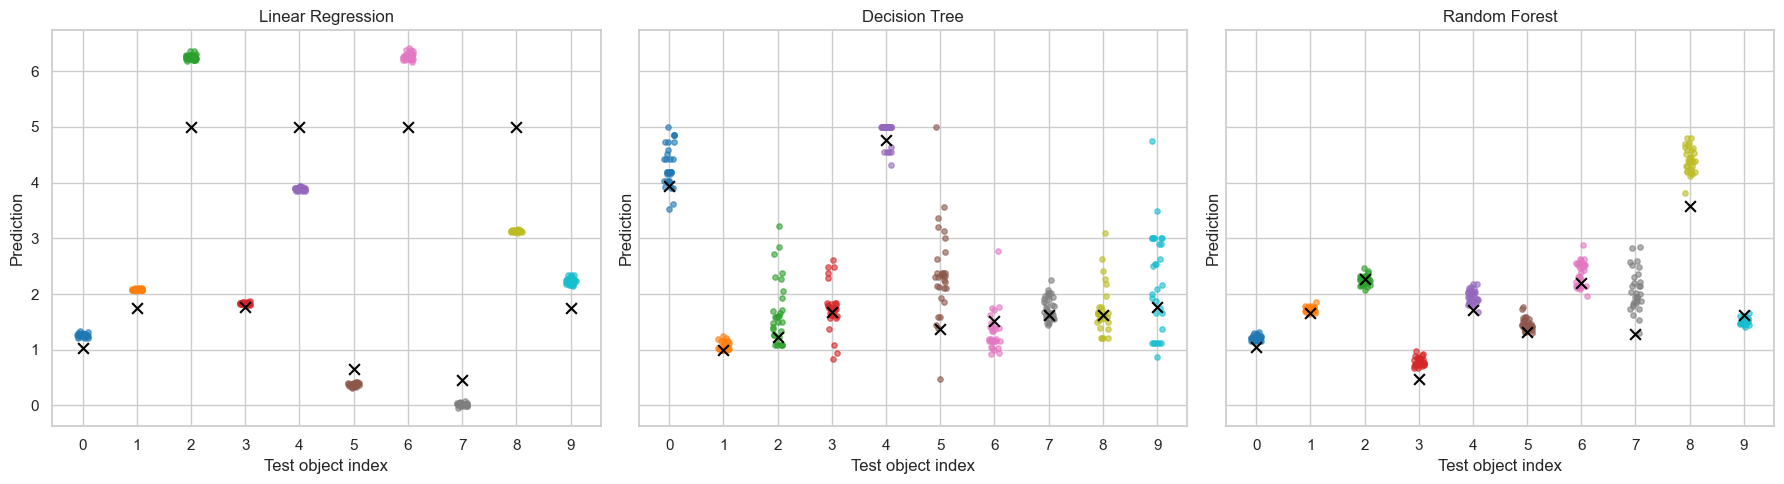

In [53]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, (name, model) in zip(axes, models.items()):
    plt.sca(ax)
    plot_predictions(model, X, y, num_runs=30, num_test_objects=10, title=name)
plt.tight_layout()
plt.show()

**Ответ:**
Все совпало с ранее сделанными выводами, на первом рисунке линейная модель, и у нее очень смещенный прогноз, но довольно кучный.
На втором рисунке тоже имеет место смущения, но явно заметен большой разброс в предсказаниях.
На третьем рисунке у нас самые лучшие результаты и довольно кучные, но все еще наблюдается небольшое смещение, хоть и в наименьшей степени. 